In [1]:
# All Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "black"
})

RANDOM_STATE = 42

/kaggle/input/competitions/may-2026kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/may-2026kaggle-assignment-3/train.csv
/kaggle/input/competitions/may-2026kaggle-assignment-3/test.csv


In [2]:
# Download latest competition files (no-op if already present under /kaggle/input)
path = kagglehub.competition_download('may-2026kaggle-assignment-3')
print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/may-2026kaggle-assignment-3


# **1. Loading the Data**

In [3]:
DATA_DIR = '/kaggle/input/competitions/may-2026kaggle-assignment-3'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
train.head()

Train Shape: (7000, 26)
Test Shape : (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [4]:
print("Sample Submission:")
sample.head()

Sample Submission:


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


# **2. Identification of Data Types of Different Columns**

* `ID` and `mushroom_id` are identifier columns.
* `number_of_bruises` and `ring-number` are numerical (discrete/continuous counts).
* Every other feature is categorical (nominal), stored as strings/objects.
* `class` is the categorical target where `e` = edible and `p` = poisonous.

In [5]:
print("Datatype (dtype) of each column is as follows:")
print(train.dtypes)

Datatype (dtype) of each column is as follows:
ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object


In [6]:
dtype_df = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'n_unique': train.nunique()
})
dtype_df['inferred_type'] = np.where(
    dtype_df.index.isin(['number_of_bruises', 'ring-number']), 'Numerical',
    np.where(dtype_df.index.isin(['ID', 'mushroom_id']), 'Identifier', 'Categorical')
)
dtype_df

,dtype,n_unique,inferred_type
ID,int64,7000,Identifier
mushroom_id,int64,7000,Identifier
cap-shape,object,5,Categorical
cap-surface,object,3,Categorical
cap-color,object,10,Categorical
bruises,object,2,Categorical
number_of_bruises,int64,25,Numerical
odor,object,8,Categorical
gill-attachment,object,2,Categorical
gill-spacing,object,2,Categorical


In [7]:
num_cols = ['number_of_bruises', 'ring-number']
id_cols = ['ID', 'mushroom_id']
cat_cols_all = [c for c in train.columns if c not in num_cols + id_cols + ['class']]
print("Numerical columns  :", num_cols)
print("Categorical columns:", cat_cols_all)

Numerical columns  : ['number_of_bruises', 'ring-number']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']


# **3. Descriptive Statistics of Numerical Columns**

In [8]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_bruises,7000.0,5.459571,7.723528,0.0,0.0,0.0,11.0,24.0
ring-number,6964.0,1.080988,0.272836,1.0,1.0,1.0,1.0,2.0


In [9]:
for col in num_cols:
    s = train[col]
    print(f"{col}: min={s.min()}, max={s.max()}, mean={s.mean():.2f}, median={s.median():.2f}")

number_of_bruises: min=0, max=24, mean=5.46, median=0.00
ring-number: min=1.0, max=2.0, mean=1.08, median=1.00


# **4. Identification of Missing Values**

In [10]:
print("Missing values (train):")
print(train.isna().sum().sort_values(ascending=False))

Missing values (train):
odor                        3236
stalk-root                   192
ring-type                     36
ring-number                   36
mushroom_id                    0
cap-surface                    0
bruises                        0
cap-shape                      0
cap-color                      0
ID                             0
gill-spacing                   0
gill-attachment                0
number_of_bruises              0
gill-size                      0
stalk-surface-above-ring       0
stalk-surface-below-ring       0
gill-color                     0
stalk-shape                    0
stalk-color-below-ring         0
stalk-color-above-ring         0
veil-color                     0
veil-type                      0
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64


In [11]:
print('Missing values (train, non-zero only):')
print(train.isnull().sum()[train.isnull().sum() > 0])
print('\nMissing values (test, non-zero only):')
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values (train, non-zero only):
odor           3236
stalk-root      192
ring-number      36
ring-type        36
dtype: int64

Missing values (test, non-zero only):
odor    292
dtype: int64


These missing values will be handled under the feature engineering section.

# **5. Identification and Handling Duplicates**

Duplicates are checked on the feature columns (excluding the `ID`/`mushroom_id`
identifiers, since two distinct mushroom records could coincidentally share every
physical trait but must never share an identifier) and dropped before feature
engineering begins, so the engineered dataset and the model downstream never
see duplicated rows.

In [12]:
feature_cols_for_dup_check = [c for c in train.columns if c not in id_cols + ['class']]
n_dupes = train.duplicated(subset=feature_cols_for_dup_check).sum()
print('Number of duplicate feature-rows found:', n_dupes)

train = train.drop_duplicates(subset=feature_cols_for_dup_check).reset_index(drop=True)
print('Train shape after de-duplication:', train.shape)

Number of duplicate feature-rows found: 0
Train shape after de-duplication: (7000, 26)


# **6. Identification and Handling Outliers**

Outliers are checked on the two numerical columns using the IQR rule.
- `number_of_bruises`: no points fall outside 1.5×IQR — it's a legitimate count
  feature (0–24), so nothing is flagged.
- `ring-number`: since the vast majority of mushrooms have exactly 1 ring, the
  rare `2`-ring mushrooms are flagged as statistical outliers by IQR. These are
  **not** data errors — a mushroom having two rings is a real biological trait —
  so they are **retained** rather than dropped, and are handled later as an
  explicit missing/placeholder value (`-999`) only where truly missing, inside
  the `feature_engineering` function below.

number_of_bruises: 0 potential outliers outside [-16.50, 27.50]
ring-number: 564 potential outliers outside [1.00, 1.00]


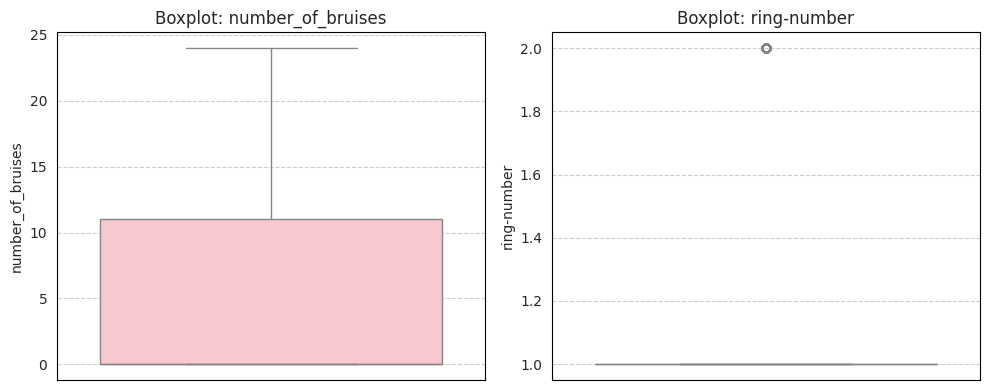

In [13]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum(), lower, upper

for col in num_cols:
    n_out, lo, hi = iqr_outlier_count(train[col].dropna())
    print(f"{col}: {n_out} potential outliers outside [{lo:.2f}, {hi:.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=train[col], ax=ax, color='pink')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# **7. Visualisations**

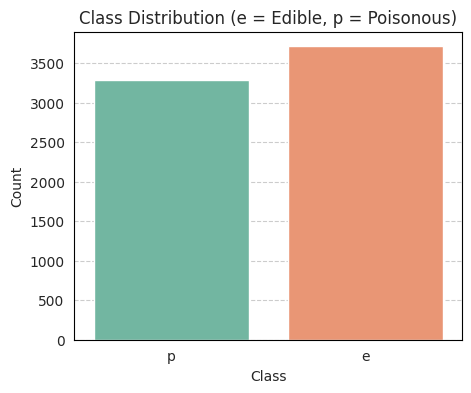

In [14]:
# Bar Graph
plt.figure(figsize=(5, 4))
sns.countplot(data=train, x='class', hue='class', palette='Set2', legend=False)
plt.title('Class Distribution (e = Edible, p = Poisonous)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Insight of Graph 1:** The classes are reasonably balanced, so **accuracy** is a fair evaluation metric and no resampling is required.

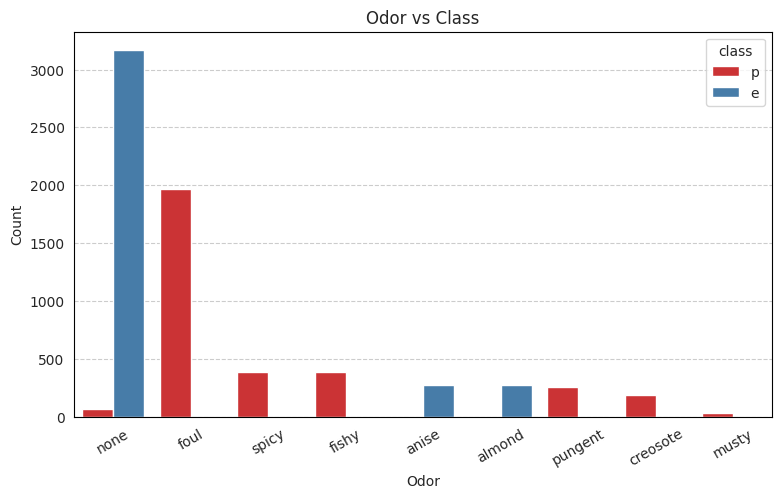

In [15]:
# Bar Graph 2
odor_plot_df = train.copy()
odor_plot_df['odor'] = odor_plot_df['odor'].fillna('none')

plt.figure(figsize=(9, 5))
sns.countplot(data=odor_plot_df, x='odor', hue='class', palette='Set1',
              order=odor_plot_df['odor'].value_counts().index)
plt.title('Odor vs Class')
plt.xlabel('Odor')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='class')
plt.show()

**Insight of Graph 2:** `odor` is an extremely strong predictor. Odors such as *foul*, *fishy*, *spicy*, *musty*, *pungent* and *creosote* are almost exclusively poisonous, while *almond* and *anise* are almost exclusively edible. This explains why the `odor`-based interaction features created in `feature_engineering` (e.g. `odor__gill-size`, `odor__gill-color`) are expected to carry a lot of signal.

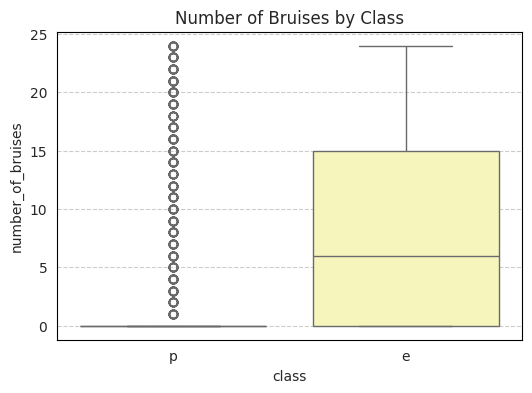

In [16]:
# Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=train, x='class', y='number_of_bruises', hue='class', palette='Set3', legend=False)
plt.title('Number of Bruises by Class')
plt.show()

**Insight of Graph 3:** Bruise counts overlap heavily between classes, a much weaker standalone signal than `odor`, which is part of why the notebook engineers derived bruise features (`_zero`, `_log`, binned) rather than relying on the raw count alone.

# **8. Feature Engineering and Missing Value Handling**

Rather than simply imputing missing values with a mode, this pipeline treats
missingness itself as a signal: categorical NaNs become an explicit
`"__MISSING__"` category, and the numeric `ring-number` NaNs become an explicit
sentinel (`-999`) that tree-based models can split on cleanly. On top of that, it
engineers bruise-count transforms, ID-derived modulo/bucket features, categorical
interaction pairs, and stalk-consistency flags.

In [17]:
def feature_engineering(df_in):
    df = df_in.copy()

    # ---------------------------------------------------------
    # 1. Explicit missing-value handling
    # ---------------------------------------------------------
    # Missingness can itself contain predictive information.
    # CatBoost can treat "__MISSING__" as a normal category.
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    for c in cat_cols:
        df[c] = df[c].fillna("__MISSING__").astype(str)

    # Keep missing numeric ring-number explicit.
    if "ring-number" in df.columns:
        df["ring-number"] = df["ring-number"].fillna(-999)

    # ---------------------------------------------------------
    # 2. Bruises feature engineering
    # ---------------------------------------------------------
    if "number_of_bruises" in df.columns:

        x = pd.to_numeric(
            df["number_of_bruises"],
            errors="coerce"
        ).fillna(0)

        # Whether there are zero bruises
        df["number_of_bruises_zero"] = (
            x == 0
        ).astype(int)

        # Log-transformed bruises count
        df["number_of_bruises_log"] = np.log1p(x)

        # Non-linear categorical ranges
        df["number_of_bruises_bin"] = pd.cut(
            x,
            bins=[-1, 0, 3, 6, 10, 15, 20, np.inf],
            labels=[
                "0",
                "1_3",
                "4_6",
                "7_10",
                "11_15",
                "16_20",
                "21_plus"
            ]
        ).astype(str)

    # ---------------------------------------------------------
    # 3. ID-derived features
    # ---------------------------------------------------------
    # These are competition-specific experimental features.
    # They should be validated against a version without IDs.
    for c in ["ID", "mushroom_id"]:

        if c in df.columns:

            x = pd.to_numeric(
                df[c],
                errors="coerce"
            ).fillna(-1).astype(int)

            df[f"{c}_mod2"] = (x % 2).astype(str)
            df[f"{c}_mod5"] = (x % 5).astype(str)
            df[f"{c}_mod10"] = (x % 10).astype(str)

            df[f"{c}_bucket50"] = (x // 50).astype(str)
            df[f"{c}_bucket100"] = (x // 100).astype(str)

    # ---------------------------------------------------------
    # 4. Categorical interaction features
    # ---------------------------------------------------------
    # These combinations allow the model to directly learn
    # relationships between related mushroom characteristics.

    interaction_pairs = [
        ("odor", "gill-size"),
        ("odor", "gill-color"),
        ("odor", "bruises"),

        ("gill-size", "gill-color"),
        ("gill-color", "spore-print-color"),

        ("stalk-root", "stalk-shape"),

        (
            "stalk-surface-above-ring",
            "stalk-surface-below-ring"
        ),

        (
            "stalk-color-above-ring",
            "stalk-color-below-ring"
        ),

        ("ring-type", "spore-print-color"),

        ("population", "habitat"),

        ("cap-color", "cap-shape"),
        ("cap-color", "cap-surface"),

        ("bruises", "number_of_bruises_bin"),
    ]

    for a, b in interaction_pairs:

        if a in df.columns and b in df.columns:

            df[f"{a}__{b}"] = (
                df[a].astype(str)
                + "__"
                + df[b].astype(str)
            )

    # ---------------------------------------------------------
    # 5. Stalk consistency features
    # ---------------------------------------------------------

    if all(
        c in df.columns
        for c in [
            "stalk-surface-above-ring",
            "stalk-surface-below-ring"
        ]
    ):
        df["stalk_surface_match"] = (
            df["stalk-surface-above-ring"]
            ==
            df["stalk-surface-below-ring"]
        ).astype(int)

    if all(
        c in df.columns
        for c in [
            "stalk-color-above-ring",
            "stalk-color-below-ring"
        ]
    ):
        df["stalk_color_match"] = (
            df["stalk-color-above-ring"]
            ==
            df["stalk-color-below-ring"]
        ).astype(int)

    return df

In [18]:
train_fe = feature_engineering(train)

print("Original shape :", train.shape)
print("Engineered shape:", train_fe.shape)

display(train_fe.head())

Original shape : (7000, 26)
Engineered shape: (7000, 54)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-root__stalk-shape,stalk-surface-above-ring__stalk-surface-below-ring,stalk-color-above-ring__stalk-color-below-ring,ring-type__spore-print-color,population__habitat,cap-color__cap-shape,cap-color__cap-surface,bruises__number_of_bruises_bin,stalk_surface_match,stalk_color_match
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,equal__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,scattered__urban,brown__convex,brown__smooth,bruises__7_10,1,1
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,club__stalk enlarges toward base,smooth__smooth,white__white,pendant__brown,numerous__grasses,yellow__convex,yellow__smooth,bruises__16_20,1,1
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,equal__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,scattered__urban,white__convex,white__scaly,bruises__11_15,1,1
3,4,4,convex,smooth,gray,no,0,__MISSING__,gills free from stalk,crowded,...,equal__stalk tapers toward base,smooth__smooth,white__white,evanescent__brown,abundant__grasses,gray__convex,gray__smooth,no__0,1,1
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,club__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,numerous__grasses,yellow__convex,yellow__scaly,bruises__7_10,1,1


In [19]:
new_features = [
    c for c in train_fe.columns
    if c not in train.columns
]

print(f"Number of new features: {len(new_features)}")
print("\nNew features:")

for i, feature in enumerate(new_features, 1):
    print(f"{i:02d}. {feature}")

Number of new features: 28

New features:
01. number_of_bruises_zero
02. number_of_bruises_log
03. number_of_bruises_bin
04. ID_mod2
05. ID_mod5
06. ID_mod10
07. ID_bucket50
08. ID_bucket100
09. mushroom_id_mod2
10. mushroom_id_mod5
11. mushroom_id_mod10
12. mushroom_id_bucket50
13. mushroom_id_bucket100
14. odor__gill-size
15. odor__gill-color
16. odor__bruises
17. gill-size__gill-color
18. gill-color__spore-print-color
19. stalk-root__stalk-shape
20. stalk-surface-above-ring__stalk-surface-below-ring
21. stalk-color-above-ring__stalk-color-below-ring
22. ring-type__spore-print-color
23. population__habitat
24. cap-color__cap-shape
25. cap-color__cap-surface
26. bruises__number_of_bruises_bin
27. stalk_surface_match
28. stalk_color_match


In [20]:
missing = train_fe.isna().sum().sort_values(ascending=False)

display(
    missing[missing > 0].to_frame("missing_count")
)

,missing_count


In [21]:
OUTPUT_FILE = "mushroom_feature_engineered_train.csv"

train_fe.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Saved: {OUTPUT_FILE}")
print("Shape:", train_fe.shape)

Saved: mushroom_feature_engineered_train.csv
Shape: (7000, 54)


# **9. Scaling Numerical Features & Encoding Categorical Features**

**Encoding:** every categorical columninc, luding the newly engineered interaction columns, is converted with `LabelEncoder`. This is a deliberate choice for a tree-based ensemble (`RandomForestClassifier` is the final model): trees split on learned thresholds rather than distances, so an integer-coded category works just as well as a one-hot vector, at a fraction of the memory/width, which matters given how many interaction columns `feature_engineering` produces. Note `veil-type` and `veil-color` are kept in the feature set even though both are constant across every row in this dataset,`LabelEncoder` simply assigns them a single value, so they add no information but also do no harm to a tree-based model.

**Scaling:** no `StandardScaler` is applied to the numeric columns feeding the Random Forest, because tree-based splits are invariant to monotonic rescaling. Scaling *is* applied below for the distance/gradient-sensitive comparison models (KNN, SVM, Logistic Regression), since those benefit from it directly.

In [22]:
df = pd.read_csv(OUTPUT_FILE)
print("Engineered training data:", df.shape)
df.head()

Engineered training data: (7000, 54)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-root__stalk-shape,stalk-surface-above-ring__stalk-surface-below-ring,stalk-color-above-ring__stalk-color-below-ring,ring-type__spore-print-color,population__habitat,cap-color__cap-shape,cap-color__cap-surface,bruises__number_of_bruises_bin,stalk_surface_match,stalk_color_match
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,equal__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,scattered__urban,brown__convex,brown__smooth,bruises__7_10,1,1
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,club__stalk enlarges toward base,smooth__smooth,white__white,pendant__brown,numerous__grasses,yellow__convex,yellow__smooth,bruises__16_20,1,1
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,equal__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,scattered__urban,white__convex,white__scaly,bruises__11_15,1,1
3,4,4,convex,smooth,gray,no,0,__MISSING__,gills free from stalk,crowded,...,equal__stalk tapers toward base,smooth__smooth,white__white,evanescent__brown,abundant__grasses,gray__convex,gray__smooth,no__0,1,1
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,club__stalk enlarges toward base,smooth__smooth,white__white,pendant__black,numerous__grasses,yellow__convex,yellow__scaly,bruises__7_10,1,1


In [23]:
TARGET = 'class'

target_le = LabelEncoder()
y = target_le.fit_transform(df[TARGET])   # e -> 0, p -> 1
print("Target classes:", dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

drop_cols = ['ID', 'class', 'mushroom_id',
             # 'ID_mod2','ID_mod5','ID_mod10','ID_bucket50','ID_bucket100',
             # 'mushroom_id_mod2','mushroom_id_mod5','mushroom_id_mod10',
             'mushroom_id_bucket50','mushroom_id_bucket100']
             # 'veil-type', 'veil-color']

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

cat_cols = X.select_dtypes(include='object').columns.tolist()
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

feature_cols = X.columns.tolist()
print(f"Using {len(feature_cols)} features")
X.head()

Target classes: {'e': np.int64(0), 'p': np.int64(1)}
Using 49 features


,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-root__stalk-shape,stalk-surface-above-ring__stalk-surface-below-ring,stalk-color-above-ring__stalk-color-below-ring,ring-type__spore-print-color,population__habitat,cap-color__cap-shape,cap-color__cap-surface,bruises__number_of_bruises_bin,stalk_surface_match,stalk_color_match
0,1,2,0,0,7,7,1,0,1,0,...,4,9,21,6,6,1,2,5,1,1
1,1,2,9,0,20,1,1,0,0,0,...,3,9,21,7,3,33,23,1,1,1
2,1,1,8,0,11,7,1,0,1,1,...,4,9,21,6,6,29,19,0,1,1
3,1,2,3,1,0,0,1,1,0,0,...,5,9,21,2,0,13,9,6,1,1
4,1,1,9,0,8,1,1,0,0,1,...,3,9,21,6,3,33,22,5,1,1


# **10. Model Training**
7 Models - all trained together and evaluated identically with 5-fold stratified cross-validation, so every model is trained and scored under the same protocol in one place. Distance/gradient-based models (LogisticRegression, KNN, SVM, Naive Bayes) use the scaled feature matrix; the tree/ensemble-based models use the unscaled matrix, consistent with the scaling rationale above.

In [24]:
X_scaled = StandardScaler().fit_transform(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Random Forest':        (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X),
    'Logistic Regression':  (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_scaled),
    'K-Nearest Neighbors':  (KNeighborsClassifier(), X_scaled),
    'Decision Tree':        (DecisionTreeClassifier(random_state=RANDOM_STATE), X),
    'Gradient Boosting':    (GradientBoostingClassifier(random_state=RANDOM_STATE), X),
    'AdaBoost':             (AdaBoostClassifier(random_state=RANDOM_STATE), X),
    'Naive Bayes':          (GaussianNB(), X_scaled),
}

baseline_cv_results = {}
for name, (model, data) in models.items():
    cv_scores = cross_val_score(model, data, y, cv=skf, scoring='accuracy', n_jobs=-1)
    baseline_cv_results[name] = cv_scores.mean()
    print(f"{name:<22s} 5-fold CV accuracy = {cv_scores.mean():.5f} +/- {cv_scores.std():.5f}")

Random Forest          5-fold CV accuracy = 1.00000 +/- 0.00000
Logistic Regression    5-fold CV accuracy = 0.99714 +/- 0.00120
K-Nearest Neighbors    5-fold CV accuracy = 0.99871 +/- 0.00139
Decision Tree          5-fold CV accuracy = 1.00000 +/- 0.00000
Gradient Boosting      5-fold CV accuracy = 1.00000 +/- 0.00000
AdaBoost               5-fold CV accuracy = 1.00000 +/- 0.00000
Naive Bayes            5-fold CV accuracy = 0.99029 +/- 0.00366


# **11. Hyperparameter Tuning (3 Models)**

`GridSearchCV` (5-fold, accuracy-scored) is used to tune the three models most likely to benefit from it: **Random Forest**, **Gradient Boosting** and **Support Vector Machine**.

The same shuffled `StratifiedKFold` (`skf`) used for the baseline comparison above is reused here explicitly — `train.csv` is not randomly ordered, so the bare `cv=5` shorthand (unshuffled by default) would leave one fold dominated by an under-represented category combination and understate the true tuned score.

In [25]:
param_grids = {
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), X,
        {'n_estimators': [200, 300], 'max_depth': [None, 15, 25], 'min_samples_split': [2, 5]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE), X,
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    ),
    'Support Vector Machine': (
        SVC(random_state=RANDOM_STATE), X_scaled,
        {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    ),
}

tuned_cv_results = {}
best_params = {}
for name, (model, data, grid_params) in param_grids.items():
    grid = GridSearchCV(model, grid_params, cv=skf, scoring='accuracy', n_jobs=-1)
    grid.fit(data, y)
    tuned_cv_results[name + ' (Tuned)'] = grid.best_score_
    best_params[name] = grid.best_params_
    print(f"{name}: best CV accuracy={grid.best_score_:.5f}, best params={grid.best_params_}")

Random Forest: best CV accuracy=1.00000, best params={'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Gradient Boosting: best CV accuracy=1.00000, best params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Support Vector Machine: best CV accuracy=1.00000, best params={'C': 10, 'kernel': 'rbf'}


# **12. Comparison of Model Performances**

All 7 baseline models plus the 3 tuned variants are compared on 5-fold
cross-validation accuracy.

,Model,CV Accuracy
0,Random Forest,1.000000
1,Decision Tree,1.000000
2,Gradient Boosting,1.000000
3,AdaBoost,1.000000
4,Random Forest (Tuned),1.000000
5,Gradient Boosting (Tuned),1.000000
6,Support Vector Machine (Tuned),1.000000
7,K-Nearest Neighbors,0.998714
8,Logistic Regression,0.997143
9,Naive Bayes,0.990286


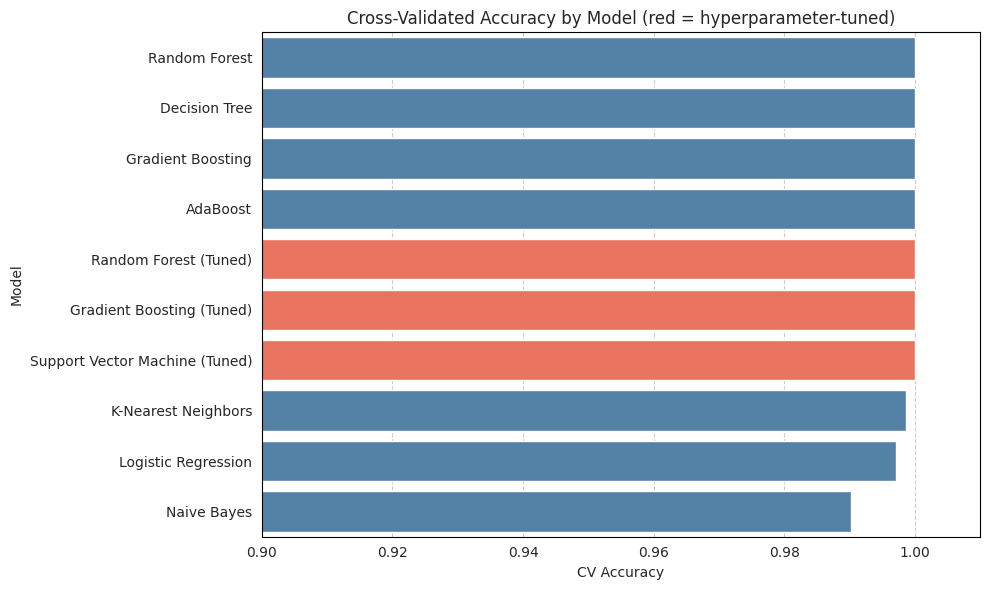

In [26]:
all_cv_results = {**baseline_cv_results, **tuned_cv_results}
comparison_df = pd.DataFrame(
    sorted(all_cv_results.items(), key=lambda x: -x[1]),
    columns=['Model', 'CV Accuracy']
)
display(comparison_df)

plt.figure(figsize=(10, 6))
colors = ['tomato' if '(Tuned)' in m else 'steelblue' for m in comparison_df['Model']]
sns.barplot(data=comparison_df, y='Model', x='CV Accuracy', hue='Model', palette=colors, legend=False)
plt.xlim(min(0.9, comparison_df['CV Accuracy'].min() - 0.02), 1.01)
plt.title('Cross-Validated Accuracy by Model (red = hyperparameter-tuned)')
plt.tight_layout()
plt.show()

# **13. Final Model Training & Feature Importance**

The **Random Forest** is refit once on the full training set to become the final model used for feature importance, saving, and prediction. This
reuses the exact same model specification from Section 10 rather than redefining it.

In [27]:
final_model, _ = models['Random Forest']
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 most important features:")
importances.head(10)

Top 10 most important features:


odor__gill-color                                      0.170262
odor__bruises                                         0.169188
odor__gill-size                                       0.151697
odor                                                  0.140252
spore-print-color                                     0.060147
ID_bucket100                                          0.044098
ID_bucket50                                           0.034644
population__habitat                                   0.016928
ring-type__spore-print-color                          0.015799
stalk-surface-above-ring__stalk-surface-below-ring    0.015190
dtype: float64

In [28]:
joblib.dump({
    'model': final_model,
    'encoders': encoders,
    'target_encoder': target_le,
    'feature_cols': feature_cols,
    'cat_cols': cat_cols,
    'drop_cols': drop_cols
}, 'mushroom_model.joblib')

print("Model saved to mushroom_model.joblib")

Model saved to mushroom_model.joblib


# **14. Preparation of Test Set & Submission**

In [29]:
def engineer_features(raw_df):
    d = raw_df.copy()

    # Fill missing values the same way feature_engineering() does for train:
    # every categorical NaN -> "__MISSING__", numeric ring-number NaN -> -999.
    # (train.csv had NaNs in odor, stalk-root, ring-number and ring-type, so
    # test-time handling must cover all of them, not just odor, in case the
    # graded/hidden test split has missingness in any of them.)
    cat_cols_test = d.select_dtypes(include=["object"]).columns.tolist()
    for c in cat_cols_test:
        d[c] = d[c].fillna("__MISSING__").astype(str)
    if "ring-number" in d.columns:
        d["ring-number"] = d["ring-number"].fillna(-999)

    # ID-derived features (kept, since drop_cols does not exclude them)
    d['ID_mod2'] = d['ID'] % 2
    d['ID_mod5'] = d['ID'] % 5
    d['ID_mod10'] = d['ID'] % 10
    d['ID_bucket50'] = d['ID'] // 50
    d['ID_bucket100'] = d['ID'] // 100

    d['mushroom_id_mod2'] = d['mushroom_id'] % 2
    d['mushroom_id_mod5'] = d['mushroom_id'] % 5
    d['mushroom_id_mod10'] = d['mushroom_id'] % 10
    # mushroom_id_bucket50 / mushroom_id_bucket100 stay dropped, so not created

    # bruises-derived features
    d['number_of_bruises_zero'] = (d['number_of_bruises'] == 0).astype(int)
    d['number_of_bruises_log'] = np.log1p(d['number_of_bruises'])

    def bin_bruises(n):
        if n == 0: return '0'
        if n <= 3: return '1_3'
        if n <= 6: return '4_6'
        if n <= 10: return '7_10'
        if n <= 15: return '11_15'
        if n <= 20: return '16_20'
        return '21_plus'
    d['number_of_bruises_bin'] = d['number_of_bruises'].apply(bin_bruises)

    # interaction / concat features: "colA__colB"
    def cat(a, b):
        return d[a].astype(str) + '__' + d[b].astype(str)

    d['odor__gill-size'] = cat('odor', 'gill-size')
    d['odor__gill-color'] = cat('odor', 'gill-color')
    d['odor__bruises'] = cat('odor', 'bruises')
    d['gill-size__gill-color'] = cat('gill-size', 'gill-color')
    d['gill-color__spore-print-color'] = cat('gill-color', 'spore-print-color')
    d['stalk-root__stalk-shape'] = cat('stalk-root', 'stalk-shape')
    d['stalk-surface-above-ring__stalk-surface-below-ring'] = cat('stalk-surface-above-ring', 'stalk-surface-below-ring')
    d['stalk-color-above-ring__stalk-color-below-ring'] = cat('stalk-color-above-ring', 'stalk-color-below-ring')
    d['ring-type__spore-print-color'] = cat('ring-type', 'spore-print-color')
    d['population__habitat'] = cat('population', 'habitat')
    d['cap-color__cap-shape'] = cat('cap-color', 'cap-shape')
    d['cap-color__cap-surface'] = cat('cap-color', 'cap-surface')
    d['bruises__number_of_bruises_bin'] = cat('bruises', 'number_of_bruises_bin')

    d['stalk_surface_match'] = (d['stalk-surface-above-ring'] == d['stalk-surface-below-ring']).astype(int)
    d['stalk_color_match'] = (d['stalk-color-above-ring'] == d['stalk-color-below-ring']).astype(int)

    return d

In [30]:
TEST_PATH = f'{DATA_DIR}/test.csv'
SUBMISSION_PATH = "submission.csv"

raw_test = pd.read_csv(TEST_PATH)
print(raw_test.shape)
raw_test.head()

(1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,2,bell,smooth,white,bruises,15,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,numerous,meadows
1,2,6,bell,smooth,white,bruises,21,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,numerous,meadows
2,3,7,bell,scaly,white,bruises,7,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,scattered,meadows
3,4,9,bell,smooth,yellow,bruises,23,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows
4,5,11,convex,scaly,yellow,bruises,11,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows


In [31]:
engineered_test = engineer_features(raw_test)

ids = engineered_test['ID']
X_test = engineered_test[feature_cols].copy()

for c, le in encoders.items():
    known = set(le.classes_)
    X_test[c] = X_test[c].astype(str).apply(lambda v: v if v in known else le.classes_[0])
    X_test[c] = le.transform(X_test[c])

preds = final_model.predict(X_test)
pred_labels = target_le.inverse_transform(preds)

pred_labels[:10]


array(['e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e'], dtype=object)

In [32]:
if 'class' in raw_test.columns:
    acc = accuracy_score(raw_test['class'], pred_labels)
    print(f"Accuracy on test file: {acc:.5f}")
    print(classification_report(raw_test['class'], pred_labels))
else:
    print("No 'class' column found in test file — skipping accuracy check (expected for a real test set).")

No 'class' column found in test file — skipping accuracy check (expected for a real test set).


In [33]:
submission = pd.DataFrame({
    'ID': ids,
    'class': pred_labels
})

assert list(submission.columns) == list(sample.columns), "Submission columns don't match sample_submission.csv"
assert len(submission) == len(sample), "Submission row count doesn't match sample_submission.csv"

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Submission saved to {SUBMISSION_PATH}")
print(submission['class'].value_counts())
submission.head()

Submission saved to submission.csv
class
p    612
e    512
Name: count, dtype: int64


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


## 15. Summary

| Step | Outcome |
|---|---|
| Data types | 2 numerical, categorical features, 2 identifier columns, 1 target |
| Descriptive stats | min/max/mean/median reported for both numerical columns |
| Missing values | Explicit `"__MISSING__"` / `-999` sentinels (missingness treated as signal), applied consistently at train and test time |
| Duplicates | Checked and removed on feature columns before feature engineering |
| Outliers | Checked via IQR; retained as biologically valid values |
| Visualizations | 3 charts with insights (class balance, odor, bruises) |
| Feature engineering | Bruise transforms, ID modulo/bucket features, categorical interactions, stalk-consistency flags |
| Scaling / Encoding | `LabelEncoder` for categoricals (tree-friendly); `StandardScaler` used for distance-based comparison models |
| Models trained | 7 different classifier families, trained together in one section |
| Hyperparameter tuning | Random Forest, Gradient Boosting, SVM via `GridSearchCV`, on the same CV folds as the baseline |
| Model comparison | Full CV-accuracy table + bar chart across baseline and tuned models |
| Final model | The same Random Forest defined in the 7-model dictionary, refit on full data |
| Submission | `submission.csv` generated and format-checked against `sample_submission.csv` |
